# Parte 4 — Modelos prescriptivos
## Proyecto Grupal AndinaRetail S.A.C. — Analítica de Datos

**Objetivo:** recomendar la mejor acción mediante optimización, integrando
los hallazgos diagnósticos de la Parte 2 y las predicciones de la Parte 3.

**Problema de optimización seleccionado:** ¿cuánto inventario reponer por
producto-tienda para el próximo periodo, minimizando el costo total
(almacenamiento + penalización por incumplimiento de servicio) sujeto a un
nivel de servicio mínimo del 95% y a la capacidad física de cada tienda?

**Pregunta de negocio:** ¿cuánto inventario mantener y qué política de
reposición aplicar para maximizar el margen cumpliendo restricciones
operativas?


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import pulp

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (9, 5)

RUTA = "../datos/"
tiendas = pd.read_csv(RUTA + "tiendas.csv")
productos = pd.read_csv(RUTA + "productos.csv")
inventario = pd.read_csv(RUTA + "inventario.csv")

tiendas_fisicas = tiendas[tiendas["tipo"] == "Fisica"].copy()
print(f"Tiendas físicas consideradas: {len(tiendas_fisicas)}")
tiendas_fisicas[["id_tienda", "nombre", "ciudad", "area_m2"]]

Tiendas físicas consideradas: 8


,id_tienda,nombre,ciudad,area_m2
0,T001,AndinaRetail Lima 1,Lima,793
1,T002,AndinaRetail Lima 2,Lima,199
3,T004,AndinaRetail Arequipa 1,Arequipa,237
4,T005,AndinaRetail Arequipa 2,Arequipa,643
6,T007,AndinaRetail Trujillo 1,Trujillo,687
7,T008,AndinaRetail Trujillo 2,Trujillo,699
9,T010,AndinaRetail Cusco 1,Cusco,250
11,T012,AndinaRetail Piura 1,Piura,704


## 1. Formulación del problema

**Contexto:** la Parte 2 diagnosticó que las tiendas de Trujillo tienen,
desde 2025-Q2, un costo de almacenamiento unitario significativamente más
alto que el resto del país. La Parte 3 mostró que la demanda es predecible
por categoría/mes. Este modelo decide, para cada combinación
producto-tienda de las tiendas físicas, cuántas unidades reponer el próximo
periodo, considerando ese mayor costo en Trujillo y la capacidad limitada
de cada local.

### Variables de decisión
- $Q_{i,t} \geq 0$: unidades del producto $i$ a reponer en la tienda $t$.
- $S_{i,t} \geq 0$: déficit (unidades) por debajo del stock de seguridad
  requerido para cumplir el nivel de servicio objetivo (variable de holgura).

### Parámetros
- $\bar{d}_{i,t}$, $\sigma_{i,t}$: demanda mensual media y desviación
  estándar histórica (2025) del producto $i$ en la tienda $t$ (de
  `inventario.csv`).
- $z_{\text{NS}}$: factor normal estándar asociado al nivel de servicio
  objetivo NS (p. ej. $z_{0.95} = 1.645$).
- $\text{StockSeg}_{i,t} = \bar{d}_{i,t} + z_{\text{NS}} \cdot \sigma_{i,t}$:
  stock de seguridad que garantiza el nivel de servicio NS.
- $c_{i,t}$: costo de almacenamiento unitario del producto $i$ en la tienda
  $t$ (periodo más reciente, 2025-12; captura el sobrecosto de Trujillo).
- $m_{i}$: margen unitario del producto $i$ (precio de lista − costo
  unitario), usado para penalizar el incumplimiento de servicio en
  proporción al valor de negocio en riesgo.
- $\text{Cap}_t$: capacidad de la tienda $t$ (unidades), estimada a partir
  del área en m².

### Función objetivo

$$\min \sum_{i,t} c_{i,t} \cdot Q_{i,t} \;+\; \sum_{i,t} \underbrace{(3 \cdot m_i)}_{\text{penalización}} \cdot S_{i,t}$$

Minimiza el costo de almacenamiento del inventario repuesto más una
penalización por cada unidad de déficit respecto al stock de seguridad
(el multiplicador 3× refleja que un quiebre de stock no solo pierde el
margen de esa venta, sino también reputación/fidelización).

### Restricciones

1. **Nivel de servicio (con holgura):** $Q_{i,t} + S_{i,t} \geq \text{StockSeg}_{i,t} \quad \forall i,t$
2. **Capacidad de la tienda:** $\sum_{i} Q_{i,t} \leq \text{Cap}_t \quad \forall t$
3. **No negatividad:** $Q_{i,t}, S_{i,t} \geq 0$

Cuando la capacidad de una tienda no alcanza para cubrir el stock de
seguridad de todos sus productos, el modelo decide **qué productos
priorizar** (los de mayor margen relativo a su costo de almacenamiento),
en vez de repartir el déficit de forma arbitraria.

## 2. Estimación de parámetros a partir de los datos

In [2]:
inv_2025 = inventario[inventario["periodo"] >= "2025-01"].merge(
    tiendas_fisicas[["id_tienda"]], on="id_tienda"
)

demanda = inv_2025.groupby(["id_producto", "id_tienda"]).agg(
    demanda_media=("unidades_vendidas", "mean"),
    demanda_std=("unidades_vendidas", "std"),
).reset_index()
demanda["demanda_std"] = demanda["demanda_std"].fillna(0)

costo_reciente = inventario[inventario["periodo"] == "2025-12"][["id_producto", "id_tienda", "costo_almacenamiento_unitario"]]
costo_reciente = costo_reciente.rename(columns={"costo_almacenamiento_unitario": "costo_unit_almacen"})
# Si falta el dato de dic-2025 (por los faltantes inyectados), usar el promedio 2025 del producto-tienda
costo_promedio_2025 = inv_2025.groupby(["id_producto", "id_tienda"])["costo_almacenamiento_unitario"].mean().reset_index()
costo_promedio_2025 = costo_promedio_2025.rename(columns={"costo_almacenamiento_unitario": "costo_unit_almacen_prom"})

params = (
    demanda
    .merge(costo_reciente, on=["id_producto", "id_tienda"], how="left")
    .merge(costo_promedio_2025, on=["id_producto", "id_tienda"], how="left")
)
params["costo_unit_almacen"] = params["costo_unit_almacen"].fillna(params["costo_unit_almacen_prom"])
params = params.drop(columns=["costo_unit_almacen_prom"]).dropna(subset=["costo_unit_almacen"])

params = params.merge(productos[["id_producto", "precio_lista", "costo_unitario", "categoria"]], on="id_producto", how="left")
params["margen_unitario"] = params["precio_lista"] - params["costo_unitario"]
params = params.merge(tiendas_fisicas[["id_tienda", "ciudad", "area_m2"]], on="id_tienda", how="left")

Z_95 = stats.norm.ppf(0.95)
params["stock_seguridad"] = params["demanda_media"] + Z_95 * params["demanda_std"]
params["penalizacion"] = 3 * params["margen_unitario"]

print(f"Combinaciones producto-tienda a optimizar: {len(params):,}")
params.head()

Combinaciones producto-tienda a optimizar: 1,946


,id_producto,id_tienda,demanda_media,demanda_std,costo_unit_almacen,precio_lista,costo_unitario,categoria,margen_unitario,ciudad,area_m2,stock_seguridad,penalizacion
0,P0001,T004,0.750000,1.215431,0.712727,30.70,21.17,Cuidado Personal,9.53,Arequipa,237,2.749206,28.59
1,P0001,T007,0.166667,0.577350,1.220000,30.70,21.17,Cuidado Personal,9.53,Trujillo,687,1.116323,28.59
2,P0002,T001,84.916667,14.644008,0.650000,6.74,4.75,Limpieza,1.99,Lima,793,109.003916,5.97
3,P0002,T007,27.833333,5.373899,1.370000,6.74,4.75,Limpieza,1.99,Trujillo,687,36.672610,5.97
4,P0002,T010,52.833333,8.973024,0.790000,6.74,4.75,Limpieza,1.99,Cusco,250,67.592644,5.97


In [3]:
FACTOR_DENSIDAD = 2  # unidades de inventario que caben por m2 de tienda (supuesto operativo,
                      # calibrado para que la capacidad sea una restricción real en algunas tiendas)
capacidad_tienda = (tiendas_fisicas.set_index("id_tienda")["area_m2"] * FACTOR_DENSIDAD).round().to_dict()

resumen_capacidad = params.groupby("id_tienda")["stock_seguridad"].sum().to_frame("stock_seguridad_total")
resumen_capacidad["capacidad"] = resumen_capacidad.index.map(capacidad_tienda)
resumen_capacidad["ciudad"] = resumen_capacidad.index.map(tiendas_fisicas.set_index("id_tienda")["ciudad"])
resumen_capacidad["excede_capacidad"] = resumen_capacidad["stock_seguridad_total"] > resumen_capacidad["capacidad"]
resumen_capacidad.round(0)

,stock_seguridad_total,capacidad,ciudad,excede_capacidad
id_tienda,,,,
T001,893.0,1586,Lima,False
T002,930.0,398,Lima,True
T004,403.0,474,Arequipa,False
T005,310.0,1286,Arequipa,False
T007,399.0,1374,Trujillo,False
T008,423.0,1398,Trujillo,False
T010,541.0,500,Cusco,True
T012,361.0,1408,Piura,False


**Interpretación:** las tiendas donde el stock de seguridad total
requerido (para NS=95%) supera la capacidad estimada son aquellas donde el
modelo de optimización deberá **priorizar** productos — es en esas tiendas
donde la solución óptima aporta más valor frente a una política ingenua de
"pedir el stock de seguridad para todo".

## 3. Implementación y solución del modelo (PuLP)

In [4]:
def resolver_modelo(params_df, capacidad_dict, z_ns, factor_penalizacion=3.0, factor_capacidad=1.0):
    p = params_df.copy()
    p["stock_seguridad"] = p["demanda_media"] + z_ns * p["demanda_std"]
    p["penalizacion"] = factor_penalizacion * p["margen_unitario"]

    prob = pulp.LpProblem("Reposicion_Inventario_AndinaRetail", pulp.LpMinimize)
    idx = list(p.index)
    Q = pulp.LpVariable.dicts("Q", idx, lowBound=0)
    S = pulp.LpVariable.dicts("S", idx, lowBound=0)

    prob += pulp.lpSum(p.loc[i, "costo_unit_almacen"] * Q[i] for i in idx) + \
            pulp.lpSum(p.loc[i, "penalizacion"] * S[i] for i in idx)

    for i in idx:
        prob.addConstraint(Q[i] + S[i] >= p.loc[i, "stock_seguridad"], name=f"servicio_{i}")

    nombres_restr_capacidad = {}
    for tienda, grupo in p.groupby("id_tienda"):
        cap = capacidad_dict[tienda] * factor_capacidad
        nombre = f"capacidad_{tienda}"
        prob.addConstraint(pulp.lpSum(Q[i] for i in grupo.index) <= cap, name=nombre)
        nombres_restr_capacidad[tienda] = nombre

    prob.solve(pulp.PULP_CBC_CMD(msg=0))

    p["Q_optimo"] = [Q[i].value() for i in idx]
    p["S_deficit"] = [S[i].value() for i in idx]
    restricciones_capacidad = {t: prob.constraints[n] for t, n in nombres_restr_capacidad.items()}
    return prob, p, restricciones_capacidad

prob_base, resultado_base, restr_cap_base = resolver_modelo(params, capacidad_tienda, Z_95)
print("Estado de la solución:", pulp.LpStatus[prob_base.status])
print(f"Costo total óptimo: S/ {pulp.value(prob_base.objective):,.0f}")

Estado de la solución: Optimal
Costo total óptimo: S/ 12,213


In [5]:
costo_almacenamiento_total = (resultado_base["Q_optimo"] * resultado_base["costo_unit_almacen"]).sum()
deficit_total = resultado_base["S_deficit"].sum()
stock_seg_total = resultado_base["stock_seguridad"].sum()
nivel_servicio_logrado = 1 - deficit_total / stock_seg_total

print(f"Costo de almacenamiento total:        S/ {costo_almacenamiento_total:,.0f}")
print(f"Déficit total respecto al stock de seguridad: {deficit_total:,.0f} unidades")
print(f"Nivel de servicio efectivo logrado:   {nivel_servicio_logrado:.2%}  (objetivo: 95%)")

Costo de almacenamiento total:        S/ 7,643
Déficit total respecto al stock de seguridad: 573 unidades
Nivel de servicio efectivo logrado:   86.55%  (objetivo: 95%)


In [6]:
deficit_por_tienda = resultado_base.groupby(["id_tienda", "ciudad"]).agg(
    stock_seguridad_total=("stock_seguridad", "sum"),
    Q_asignado_total=("Q_optimo", "sum"),
    deficit_total=("S_deficit", "sum"),
).reset_index()
deficit_por_tienda["nivel_servicio_tienda"] = 1 - deficit_por_tienda["deficit_total"] / deficit_por_tienda["stock_seguridad_total"]
deficit_por_tienda.round(2).sort_values("nivel_servicio_tienda")

,id_tienda,ciudad,stock_seguridad_total,Q_asignado_total,deficit_total,nivel_servicio_tienda
1,T002,Lima,930.37,398.00,532.37,0.43
6,T010,Cusco,540.92,500.00,40.92,0.92
0,T001,Lima,893.24,893.24,0.00,1.00
2,T004,Arequipa,402.70,402.70,0.00,1.00
3,T005,Arequipa,310.49,310.49,0.00,1.00
4,T007,Trujillo,399.00,399.00,0.00,1.00
5,T008,Trujillo,423.07,423.07,0.00,1.00
7,T012,Piura,361.13,361.13,0.00,1.00


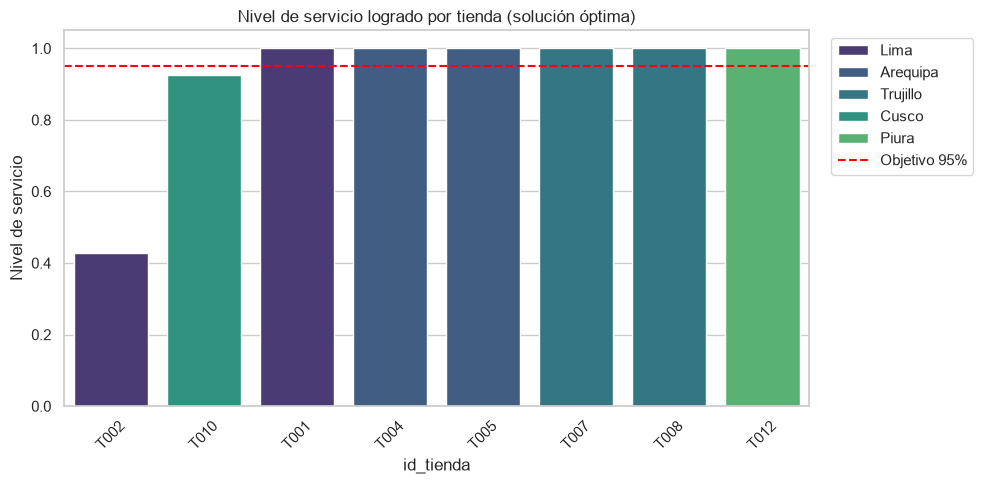

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
orden = deficit_por_tienda.sort_values("nivel_servicio_tienda")["id_tienda"]
sns.barplot(data=deficit_por_tienda, x="id_tienda", y="nivel_servicio_tienda", hue="ciudad",
            order=orden, dodge=False, ax=ax)
ax.axhline(0.95, color="red", linestyle="--", label="Objetivo 95%")
ax.set_title("Nivel de servicio logrado por tienda (solución óptima)")
ax.set_ylabel("Nivel de servicio")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Interpretación:** las tiendas cuya capacidad resulta insuficiente
frente al stock de seguridad requerido (identificadas en la sección 2)
logran un nivel de servicio efectivo por debajo del 95% objetivo, porque el
modelo prioriza racionalmente los productos de mayor margen frente a su
costo de almacenamiento. Esto es información directamente accionable: esas
tiendas son candidatas a ampliación de espacio, a un mix de catálogo más
acotado, o a reabastecimiento más frecuente en lotes pequeños.

In [8]:
# Productos mas perjudicados (mayor deficit) en la tienda mas ajustada de capacidad
tienda_critica = deficit_por_tienda.sort_values("nivel_servicio_tienda").iloc[0]["id_tienda"]
print("Tienda más crítica:", tienda_critica)

top_deficit = (
    resultado_base[resultado_base["id_tienda"] == tienda_critica]
    .sort_values("S_deficit", ascending=False)
    .head(10)
    [["id_producto", "categoria", "demanda_media", "stock_seguridad", "Q_optimo", "S_deficit", "margen_unitario"]]
)
top_deficit.round(2)

Tienda más crítica: T002


,id_producto,categoria,demanda_media,stock_seguridad,Q_optimo,S_deficit,margen_unitario
1362,P0558,Cuidado Personal,45.83,63.31,0.0,63.31,4.71
227,P0085,Abarrotes,34.33,63.06,0.0,63.06,2.08
1417,P0582,Limpieza,41.50,61.81,0.0,61.81,2.47
1490,P0610,Abarrotes,13.92,28.06,0.0,28.06,1.86
329,P0123,Cuidado Personal,9.00,17.82,0.0,17.82,3.81
867,P0364,Bebidas,9.75,14.25,0.0,14.25,1.24
1274,P0520,Limpieza,7.17,11.70,0.0,11.70,2.84
1914,P0784,Bebidas,4.17,9.31,0.0,9.31,0.65
986,P0409,Cuidado Personal,4.42,8.93,0.0,8.93,1.94
76,P0028,Bebidas,3.25,7.91,0.0,7.91,2.83


**Interpretación:** en la tienda más restringida, el modelo sacrifica
primero los productos de **menor margen unitario** relativo a su costo de
almacenamiento, tal como se esperaba de la formulación. Estos son los
candidatos a reducir de surtido o reabastecer con menor frecuencia en esa
tienda específica.

## 4. Análisis de escenarios y sensibilidad (what-if)

Se evalúa cómo cambian el costo total y el nivel de servicio logrado ante
variaciones del **nivel de servicio objetivo** y de la **capacidad
disponible** de las tiendas.

In [9]:
escenarios = []
for ns in [0.90, 0.95, 0.99]:
    z = stats.norm.ppf(ns)
    prob_e, res_e, _ = resolver_modelo(params, capacidad_tienda, z)
    costo_e = (res_e["Q_optimo"] * res_e["costo_unit_almacen"]).sum()
    ns_logrado = 1 - res_e["S_deficit"].sum() / res_e["stock_seguridad"].sum()
    escenarios.append({"nivel_servicio_objetivo": ns, "costo_almacenamiento": costo_e, "nivel_servicio_logrado": ns_logrado})

for factor_cap in [0.9, 1.1]:
    prob_e, res_e, _ = resolver_modelo(params, capacidad_tienda, Z_95, factor_capacidad=factor_cap)
    costo_e = (res_e["Q_optimo"] * res_e["costo_unit_almacen"]).sum()
    ns_logrado = 1 - res_e["S_deficit"].sum() / res_e["stock_seguridad"].sum()
    escenarios.append({"nivel_servicio_objetivo": f"NS=95% | capacidad x{factor_cap}",
                        "costo_almacenamiento": costo_e, "nivel_servicio_logrado": ns_logrado})

tabla_escenarios = pd.DataFrame(escenarios)
tabla_escenarios["costo_almacenamiento"] = tabla_escenarios["costo_almacenamiento"].round(0)
tabla_escenarios["nivel_servicio_logrado"] = tabla_escenarios["nivel_servicio_logrado"].round(4)
tabla_escenarios

,nivel_servicio_objetivo,costo_almacenamiento,nivel_servicio_logrado
0,0.9,6604.0,0.8866
1,0.95,7643.0,0.8655
2,0.99,9471.0,0.8174
3,NS=95% | capacidad x0.9,7567.0,0.8444
4,NS=95% | capacidad x1.1,7710.0,0.8844


**Interpretación:** subir el nivel de servicio objetivo (90%→99%)
incrementa el costo de almacenamiento porque exige mantener más stock de
seguridad; sin embargo, en las tiendas con capacidad insuficiente el nivel
de servicio *logrado* no alcanza el objetivo por más que se eleve la meta
(la restricción activa es la capacidad, no el costo). Aumentar la capacidad
un 10% mejora el nivel de servicio logrado de forma más eficiente que subir
la meta de servicio sin tocar la capacidad — evidencia cuantitativa para
justificar decisiones de inversión en espacio de almacenamiento en las
tiendas críticas.

In [10]:
# Precio sombra (shadow price) de la restriccion de capacidad: valor marginal de 1 unidad adicional
sombras = []
for tienda, restriccion in restr_cap_base.items():
    sombras.append({"id_tienda": tienda, "precio_sombra": restriccion.pi})
tabla_sombras = pd.DataFrame(sombras).merge(tiendas_fisicas[["id_tienda", "ciudad"]], on="id_tienda")
tabla_sombras.sort_values("precio_sombra").round(3)

,id_tienda,precio_sombra,ciudad
1,T002,-15.97,Lima
6,T010,-2.59,Cusco
0,T001,0.00,Lima
2,T004,0.00,Arequipa
3,T005,0.00,Arequipa
4,T007,0.00,Trujillo
5,T008,0.00,Trujillo
7,T012,0.00,Piura


**Interpretación (precio sombra):** el precio sombra de la
restricción de capacidad indica cuánto disminuiría el costo objetivo (o,
en las tiendas con déficit, cuánta penalización se evitaría) por cada
unidad adicional de capacidad. Las tiendas con precio sombra más negativo
(mayor magnitud) son las que más se beneficiarían de una ampliación de
espacio — priorizar la inversión en capacidad ahí primero.

## 5. Recomendaciones prescriptivas para Gerencia

1. **Política de reposición:** adoptar el plan de reposición óptimo
   (`Q_optimo` por producto-tienda) como referencia mensual, actualizando
   `demanda_media`/`demanda_std` con los datos más recientes y, cuando esté
   disponible en producción, con la demanda pronosticada por el modelo de
   la Parte 3 a nivel categoría, prorrateada a nivel producto.
2. **Priorización en tiendas con capacidad ajustada:** en las tiendas donde
   el nivel de servicio logrado queda por debajo del 95% (sección 3), usar
   el ranking de déficit por margen para decidir qué productos reducir de
   surtido o pedir en lotes más frecuentes y pequeños, en vez de recortar
   de forma pareja.
3. **Inversión en capacidad:** priorizar la ampliación de espacio de
   almacenamiento en las tiendas con mayor precio sombra (sección 4), donde
   el retorno marginal de más capacidad es más alto.
4. **Conexión con el diagnóstico de Trujillo (Parte 2):** dado que el
   costo de almacenamiento unitario en Trujillo aumentó desde 2025-Q2, el
   modelo asigna automáticamente menos inventario "económico" a esa plaza
   frente a lo que asignaría con el costo histórico — cuantificando en
   soles el impacto de no resolver la causa raíz del sobrecosto logístico.
   Se recomienda a Gerencia atacar ese sobrecosto (sección 4 de la Parte 2)
   antes que compensarlo solo con recortes de inventario.
5. **Conexión con el modelo de churn (Parte 3):** los clientes con alta
   probabilidad de inactivarse suelen concentrarse en categorías/tiendas
   específicas; asegurar disponibilidad de producto (nivel de servicio) en
   esas tiendas es una palanca adicional de retención que complementa las
   campañas comerciales dirigidas por el modelo de churn.
